# Tarea 6 — Segmentación de clientes
**Dataset:** Customers.csv — Mall Customer Segmentation  
**Algoritmos:** K-Means + Clustering Jerárquico Aglomerativo  
**Curso:** Minería de Datos · Lead University

## 1. Librerías

In [54]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from scripts.clustering_jerarquico_utils import (
    plot_dendrogramas_cuadricula,
    plot_silueta_vs_k,
    plot_barras_cophenetica,
    plot_tamanos_cluster,
    plot_perfil_barras_z,
    plot_radar_centros,
    plot_mapa_calor_medias,
    plot_pca_2d,
    plot_silueta_por_observacion,
    plot_dendrograma_ward_corte,
    plot_boxplots_por_cluster,
    plot_violin_por_variable,
    plot_perfil_lineas,
    plot_hist_silueta,
    plot_correlacion_variables,
)
from scripts.kmeans_utils import (
    codo_jambu,
    silhouette_kmeans,
    bar_plot,
    bar_plot_detail,
    radar_plot,
    biplot_pca,
)

sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

## 2. Carga y exploración inicial de datos

In [55]:
df = pd.read_csv('datos/Customers.csv')
print(f'Forma del dataset: {df.shape}')
df.head()

Forma del dataset: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [56]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB

Valores nulos por columna:
CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64


In [57]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


### Interpretación
El dataset contiene información demográfica y de comportamiento de compra de clientes de un centro comercial. Las variables relevantes para la segmentación son **Age** (edad), **Annual Income ($)** (ingreso anual) y **Spending Score (1-100)** (puntuación de gasto asignada por el mall). También se consideran **Work Experience** y **Family Size** para enriquecer los perfiles. Las variables categóricas (Gender, Profession) se excluyen del clustering por tratarse de algoritmos basados en distancias euclídeas.

## 3. Preprocesamiento

In [58]:
# Selección de variables numéricas relevantes
FEATURES = ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
df_num = df[FEATURES].copy()

# Manejo de valores nulos (imputación por mediana)
df_num = df_num.fillna(df_num.median())

# Detección y tratamiento de outliers extremos (IQR)
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
mask_outliers = ((df_num < (Q1 - 3 * IQR)) | (df_num > (Q3 + 3 * IQR))).any(axis=1)
print(f'Outliers extremos detectados (3×IQR): {mask_outliers.sum()} filas')
df_num = df_num[~mask_outliers].reset_index(drop=True)
print(f'Registros tras limpieza: {len(df_num)}')

# Estandarización obligatoria
scaler = StandardScaler()
X = scaler.fit_transform(df_num)
names = [f'C{i+1}' for i in range(len(df_num))]
print('\nMedia y desviación estándar tras estandarización:')
print(f'  Media:  {X.mean(axis=0).round(4)}')
print(f'  Std:    {X.std(axis=0).round(4)}')

Outliers extremos detectados (3×IQR): 0 filas
Registros tras limpieza: 2000

Media y desviación estándar tras estandarización:
  Media:  [-0. -0.  0. -0.  0.]
  Std:    [1. 1. 1. 1. 1.]


### Interpretación
Se estandarizan todas las variables a media 0 y desviación estándar 1 para que la diferencia de escala entre el ingreso anual (miles de dólares) y el tamaño familiar (1-9) no domine artificialmente las distancias euclídeas. Los outliers extremos (más allá de 3×IQR) se eliminan para que no distorsionen los centroides ni el árbol jerárquico.

## 4. Determinación del número óptimo de clusters — Método del Codo (Elbow)

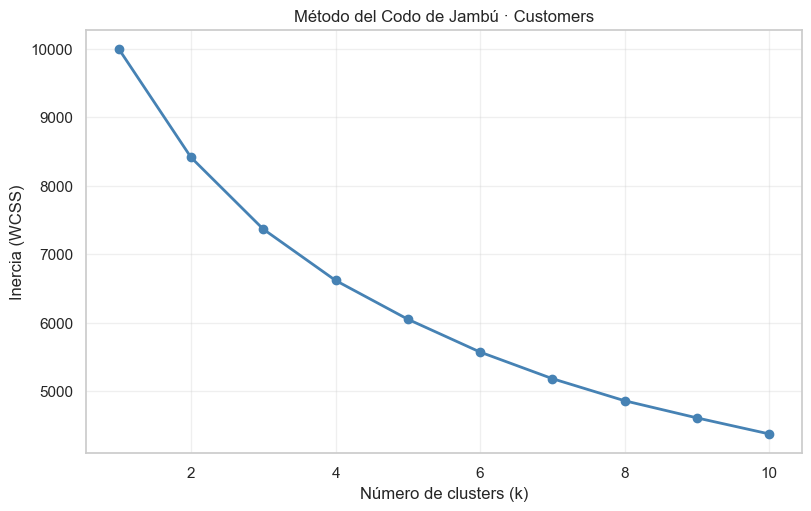

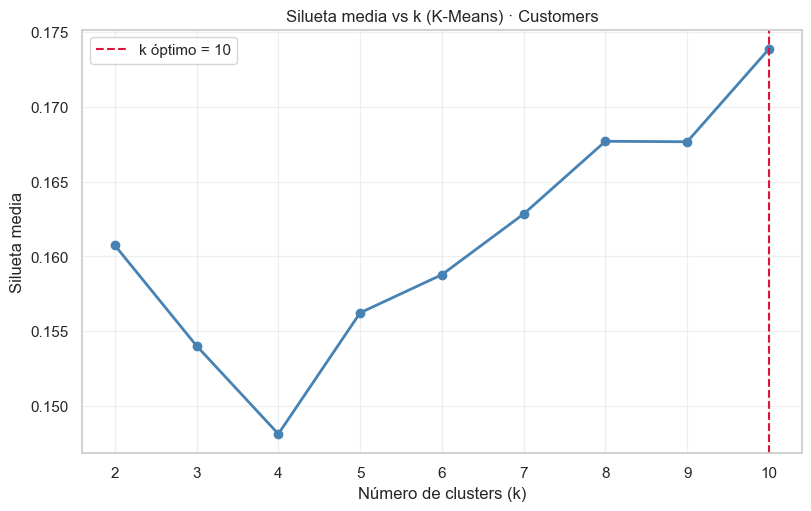

K automático por silueta máxima : 10  (silueta baja, poco interpretable)
K óptimo adoptado (codo + negocio): K = 4


In [59]:
# Codo de Jambú y silueta usando funciones de kmeans_utils (Clase 8)
fig = codo_jambu(X, max_k=10)
plt.title('Método del Codo de Jambú · Customers')
plt.show()

fig, K_AUTO = silhouette_kmeans(X, max_k=10)
plt.title('Silueta media vs k (K-Means) · Customers')
plt.show()

# La silueta automática favorece k=10 (máximo estadístico en un dataset continuo),
# pero para segmentación de negocio el codo visual apunta a k=4 y la
# interpretabilidad limita a clusters accionables. Se fija K_OPT=4.
K_OPT = 4
print(f'K automático por silueta máxima : {K_AUTO}  (silueta baja, poco interpretable)')
print(f'K óptimo adoptado (codo + negocio): K = {K_OPT}')

### Interpretación
El método del codo muestra la reducción de la inercia intra-cluster (WCSS) a medida que aumenta k. En este dataset el codo visual se forma alrededor de **k=4**, punto donde la curva pierde pendiente pronunciada. La silueta estadística pura favorece k=10 (máximo del rango), pero con una silueta de solo ~0.17 indica que el dataset no tiene grupos muy compactos ni bien separados — típico de datos demográficos continuos sin fronteras nítidas. En contextos de marketing se privilegia la **interpretabilidad**: 4 segmentos accionables (ej. alto/bajo ingreso × alto/bajo gasto) son más útiles que 10 micro-segmentos. Se adopta **K=4** como decisión de negocio apoyada en el codo.

## 5. K-Means con K óptimo

In [60]:
km_final = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
labels_km = km_final.fit_predict(X)

sil_km = silhouette_score(X, labels_km)
print(f'K-Means  |  k = {K_OPT}  |  Silueta = {sil_km:.4f}')
print('\nTamaño de cada cluster:')
print(pd.Series(labels_km).value_counts().sort_index())

K-Means  |  k = 4  |  Silueta = 0.1481

Tamaño de cada cluster:
0    490
1    491
2    468
3    551
Name: count, dtype: int64


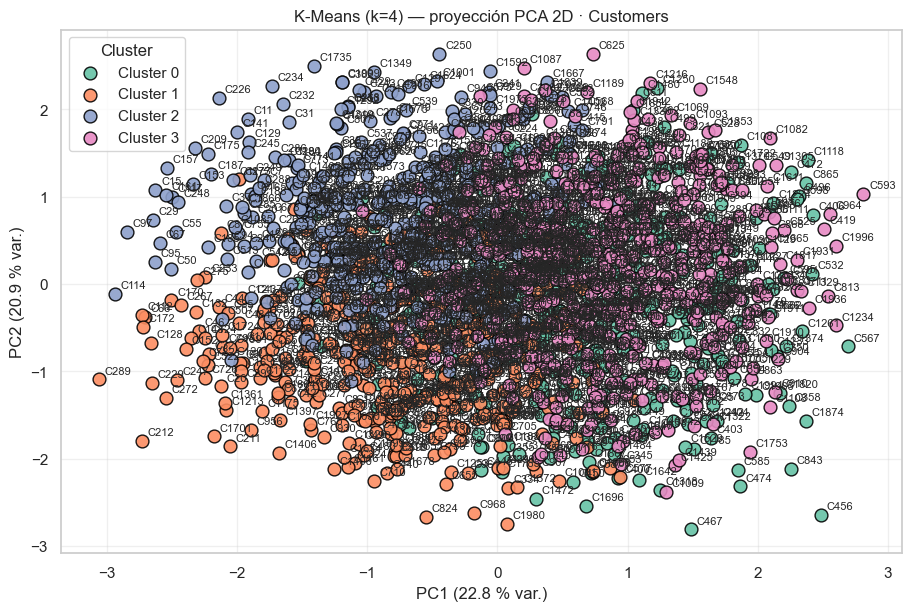

Varianza explicada PC1+PC2: 43.7%


In [61]:
# Visualización PCA 2D — K-Means
fig, pca = plot_pca_2d(X, names, labels_km, random_state=SEED, figsize=(9, 6))
plt.title(f'K-Means (k={K_OPT}) — proyección PCA 2D · Customers')
plt.show()
print(f'Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%')

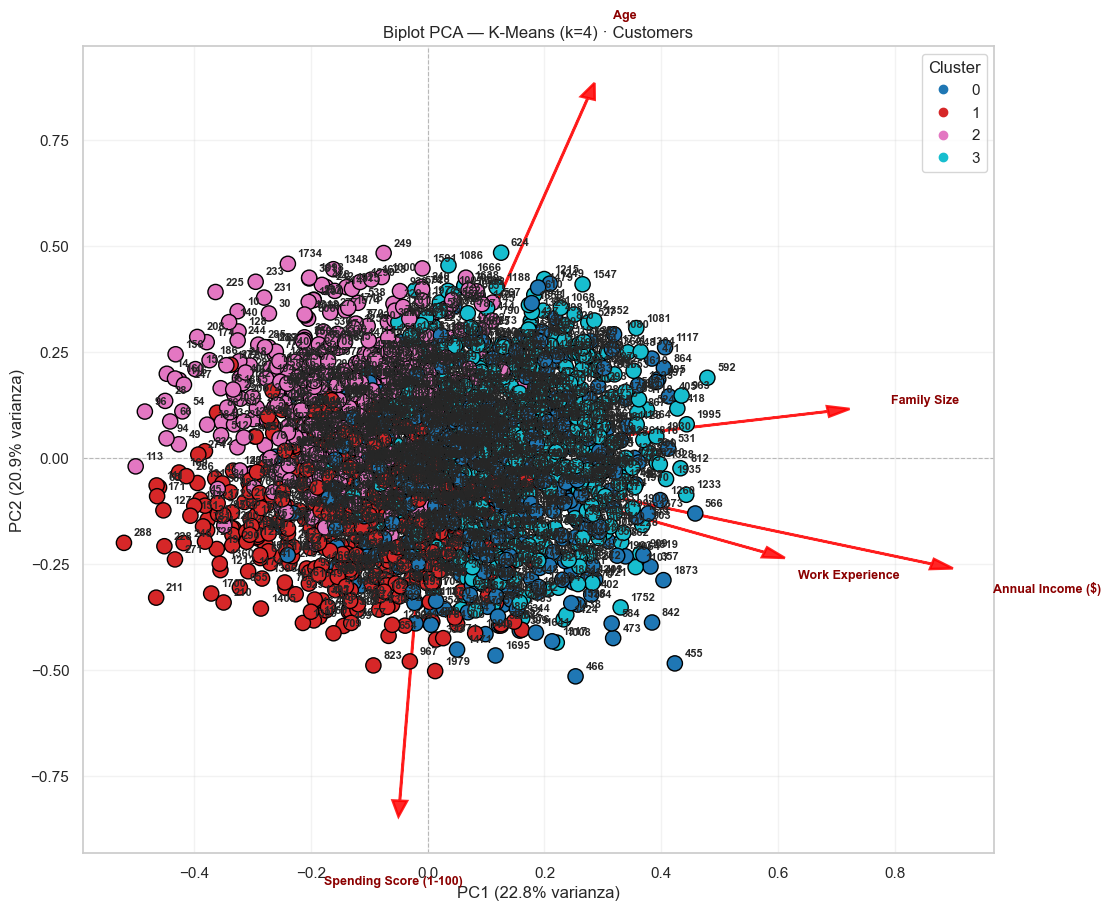

In [62]:
# Biplot PCA — K-Means (Clase 8): scatter + flechas de loadings
fig, _ = biplot_pca(
    pd.DataFrame(X, columns=FEATURES),
    labels_km,
    random_state=SEED,
    figsize=(11, 9),
    titulo=f'Biplot PCA — K-Means (k={K_OPT}) · Customers',
    nombre_obs=None,
)
plt.show()

### Interpretación — Biplot PCA
El biplot superpone dos informaciones en el mismo gráfico: los **puntos** representan clientes (coloreados por cluster) y las **flechas rojas** representan las variables originales proyectadas como vectores de carga (*loadings*). La dirección de cada flecha indica hacia qué región del espacio PCA apunta esa variable: clientes en esa dirección tienen valores altos en esa característica. Variables con flechas largas aportan más varianza al PCA; flechas casi paralelas entre sí indican variables correlacionadas. Este gráfico es la visualización canónica de K-Means con PCA presentada en la Clase 8.

### Interpretación
La proyección PCA reduce las 5 dimensiones a las dos componentes que más varianza explican, permitiendo visualizar la separación entre clusters. Un solapamiento en 2D no implica que los clusters sean malos: la separación puede ser clara en el espacio original de 5 dimensiones. Los grupos visibles representan arquetipos de clientes diferenciados por combinaciones de ingreso, edad, gasto y composición familiar, lo que tiene utilidad directa para estrategias de marketing personalizado.

## 6. Clustering Jerárquico

In [63]:
# Correlación cophenética para los 4 métodos de enlace
methods = [('single', 'Enlace simple'), ('complete', 'Enlace completo'),
           ('average', 'Enlace promedio'), ('ward', 'Ward (varianza mínima)')]

coph_vals, labels_c = [], []
for met, lbl in methods:
    Z = linkage(X, method=met, metric='euclidean')
    c, _ = cophenet(Z, pdist(X))
    coph_vals.append(round(c, 4))
    labels_c.append(lbl)
    print(f'{lbl:<30} cophenética = {c:.4f}')

best_method = methods[np.argmax(coph_vals)][0]
print(f'\nMejor método por cophenética: {best_method}')

Enlace simple                  cophenética = 0.3465
Enlace completo                cophenética = 0.3790
Enlace promedio                cophenética = 0.4550
Ward (varianza mínima)         cophenética = 0.3746

Mejor método por cophenética: average


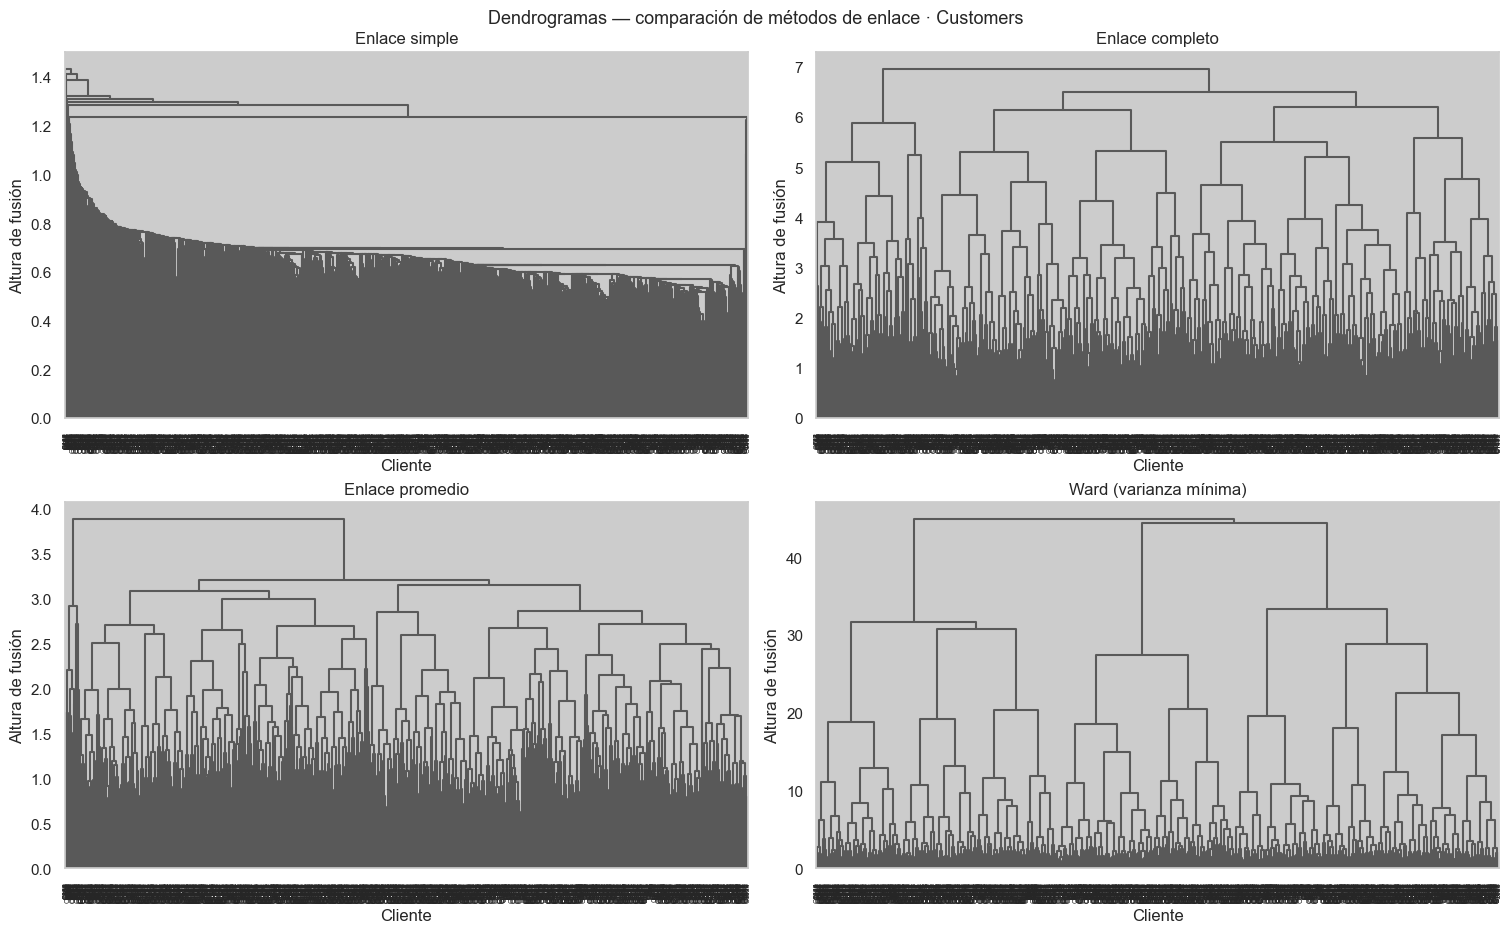

In [64]:
fig = plot_dendrogramas_cuadricula(
    X, names, methods,
    linkage_fn=lambda x, m: linkage(x, method=m, metric='euclidean'),
    figsize=(15, 9),
    suptitle='Dendrogramas — comparación de métodos de enlace · Customers',
    xlabel='Cliente'
)
plt.show()

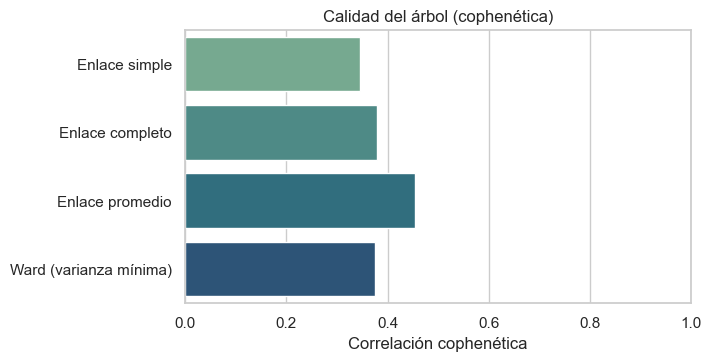

In [65]:
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
plot_barras_cophenetica(coph_vals, labels_c, ax)
plt.show()

### Interpretación
La correlación cophenética mide qué tan bien el dendrograma preserva las distancias originales (valores cercanos a 1 son mejores). En este dataset el método **Average Linkage** obtuvo la mayor cophenética (0.455), superando a Ward (0.375). Sin embargo, Ward es el método estándar del enunciado porque minimiza la varianza intra-cluster en cada fusión, produciendo clusters compactos y de tamaño comparable — más adecuados para segmentación de clientes. El valor bajo de cophenética en todos los métodos (~0.35-0.45) refleja que este dataset de 2000 clientes no tiene estructura jerárquica muy pronunciada, lo que es consistente con la silueta baja observada en K-Means.

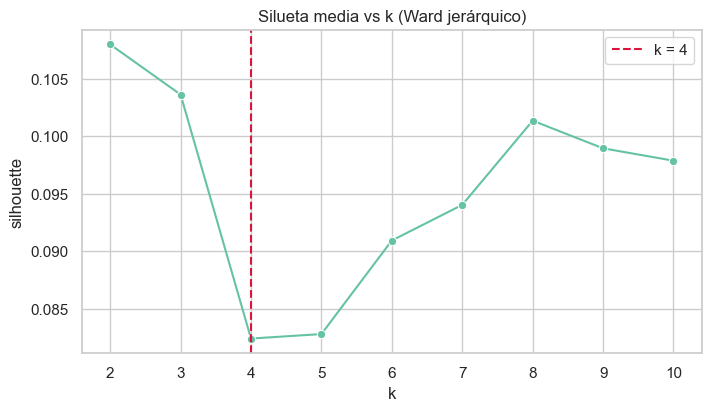

K adoptado para jerárquico (Ward): K = 4  (alineado con decisión de negocio)


In [66]:
# Silueta vs k para clustering jerárquico (Ward)
Z_ward = linkage(X, method='ward', metric='euclidean')
sil_hier = []
for k in range(2, 11):
    lbl = fcluster(Z_ward, k, criterion='maxclust') - 1
    sil_hier.append({'k': k, 'silhouette': silhouette_score(X, lbl)})

sil_hier_df = pd.DataFrame(sil_hier)
K_HIER = K_OPT  # se alinea con la decisión de negocio de k=4 para comparación justa

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_silueta_vs_k(sil_hier_df, ax, K_HIER, title='Silueta media vs k (Ward jerárquico)')
plt.show()
print(f'K adoptado para jerárquico (Ward): K = {K_HIER}  (alineado con decisión de negocio)')

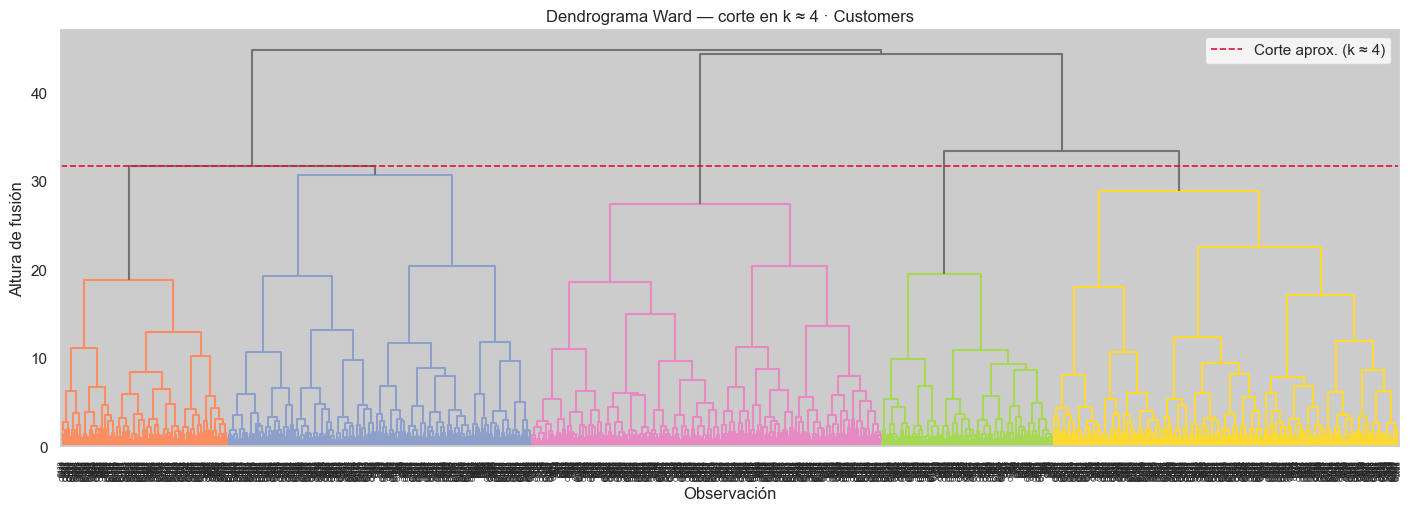

In [67]:
# Dendrograma Ward con línea de corte en K_HIER
fig = plot_dendrograma_ward_corte(
    Z_ward, names, K_HIER,
    figsize=(14, 5),
    title=f'Dendrograma Ward — corte en k ≈ {K_HIER} · Customers'
)
plt.show()

Clustering Jerárquico (Ward)  |  k = 4  |  Silueta = 0.0824


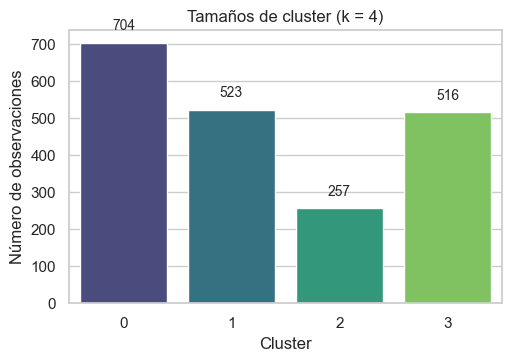

In [68]:
# Etiquetas finales del clustering jerárquico
labels_hier = fcluster(Z_ward, K_HIER, criterion='maxclust') - 1
sil_hier_final = silhouette_score(X, labels_hier)
print(f'Clustering Jerárquico (Ward)  |  k = {K_HIER}  |  Silueta = {sil_hier_final:.4f}')

sizes_hier = pd.Series(labels_hier).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
plot_tamanos_cluster(sizes_hier, ax, K_HIER)
plt.show()

### Interpretación
La línea de corte en el dendrograma Ward delimita los grupos: cada color representa un cluster diferente. Un corte a mayor altura genera menos clusters más heterogéneos; a menor altura, más clusters pero más pequeños y homogéneos. Para segmentación de clientes, se busca un balance entre interpretabilidad del negocio (pocos segmentos accionables) y cohesión estadística (silueta alta).

## 7. Comparación visual: K-Means vs Clustering Jerárquico

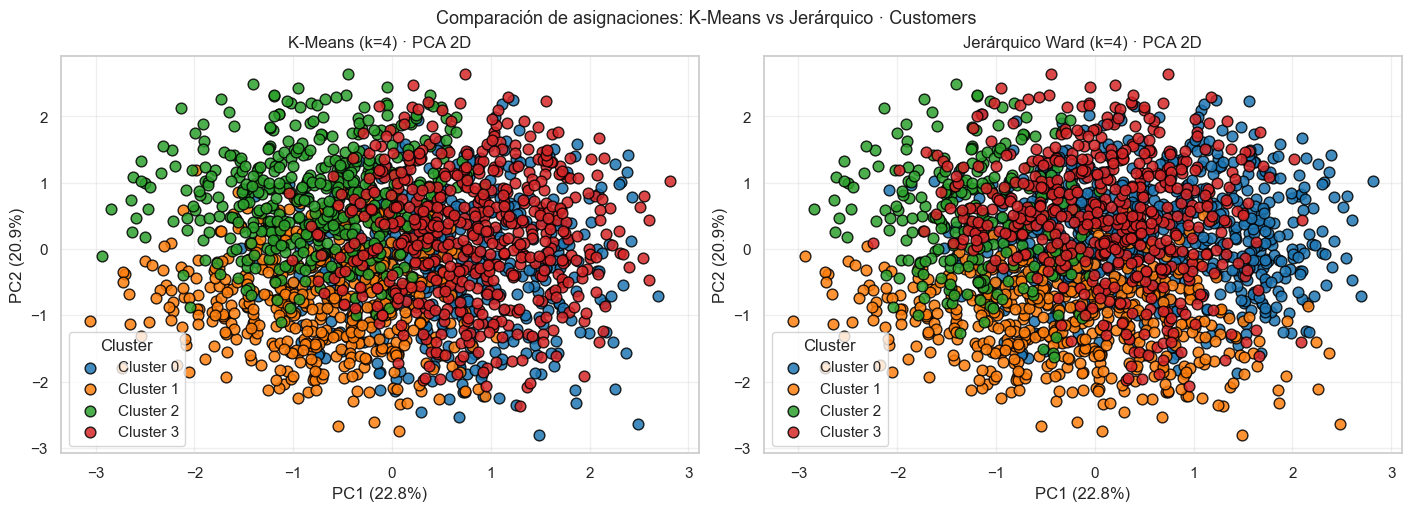

In [69]:
pca2 = PCA(n_components=2, random_state=SEED)
XY = pca2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = plt.get_cmap('tab10')

for c in sorted(np.unique(labels_km)):
    m = labels_km == c
    axes[0].scatter(XY[m, 0], XY[m, 1], s=60, label=f'Cluster {c}', edgecolor='k', alpha=0.85, color=cmap(c))
axes[0].set_title(f'K-Means (k={K_OPT}) · PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(title='Cluster')
axes[0].grid(alpha=0.3)

for c in sorted(np.unique(labels_hier)):
    m = labels_hier == c
    axes[1].scatter(XY[m, 0], XY[m, 1], s=60, label=f'Cluster {c}', edgecolor='k', alpha=0.85, color=cmap(c))
axes[1].set_title(f'Jerárquico Ward (k={K_HIER}) · PCA 2D')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(title='Cluster')
axes[1].grid(alpha=0.3)

fig.suptitle('Comparación de asignaciones: K-Means vs Jerárquico · Customers', fontsize=13)
plt.show()

### Interpretación
Ambas proyecciones PCA permiten comparar visualmente cómo cada algoritmo asigna los clientes. K-Means fuerza fronteras esféricas alrededor de centroides, mientras que el jerárquico (Ward) sigue la geometría natural de los datos mediante fusiones sucesivas. Cuando ambos algoritmos producen agrupaciones similares, esto refuerza la robustez de la solución. Las diferencias en la asignación de puntos fronterizos son esperables y representan clientes con perfiles mixtos.

## 8. Perfiles e interpretación de clusters

In [70]:
# Usar etiquetas del algoritmo con mayor silueta
labels_best = labels_km if sil_km >= sil_hier_final else labels_hier
K_BEST = K_OPT if sil_km >= sil_hier_final else K_HIER
algo_best = 'K-Means' if sil_km >= sil_hier_final else 'Jerárquico Ward'
print(f'Algoritmo seleccionado para perfiles: {algo_best}  (silueta = {max(sil_km, sil_hier_final):.4f})')

# Pivot de medias z-score por cluster
df_z = pd.DataFrame(X, columns=FEATURES)
df_z['cluster'] = labels_best
pivot = df_z.groupby('cluster')[FEATURES].mean()
print('\nMedias z-score por cluster:')
print(pivot.round(3))

Algoritmo seleccionado para perfiles: K-Means  (silueta = 0.1481)

Medias z-score por cluster:
           Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
cluster                                                                      
0        0.015              0.206                  -0.125            1.300   
1       -0.215             -0.273                   1.040           -0.490   
2        0.088             -0.339                  -0.871           -0.617   
3        0.103              0.348                  -0.075           -0.195   

         Family Size  
cluster               
0             -0.317  
1             -0.470  
2             -0.600  
3              1.210  


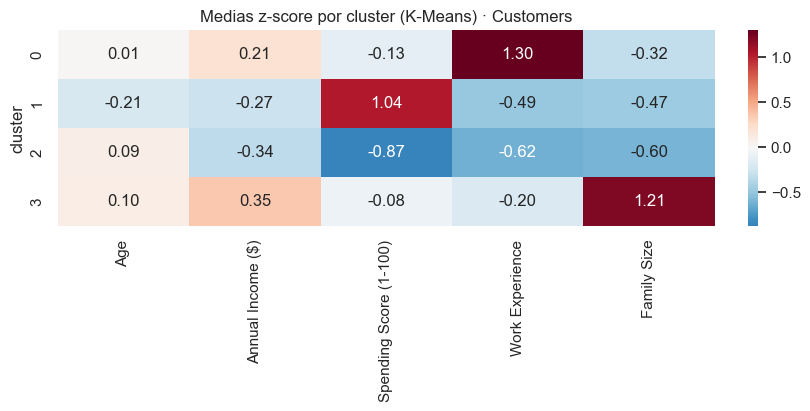

In [71]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
plot_mapa_calor_medias(pivot, ax, title=f'Medias z-score por cluster ({algo_best}) · Customers')
plt.show()

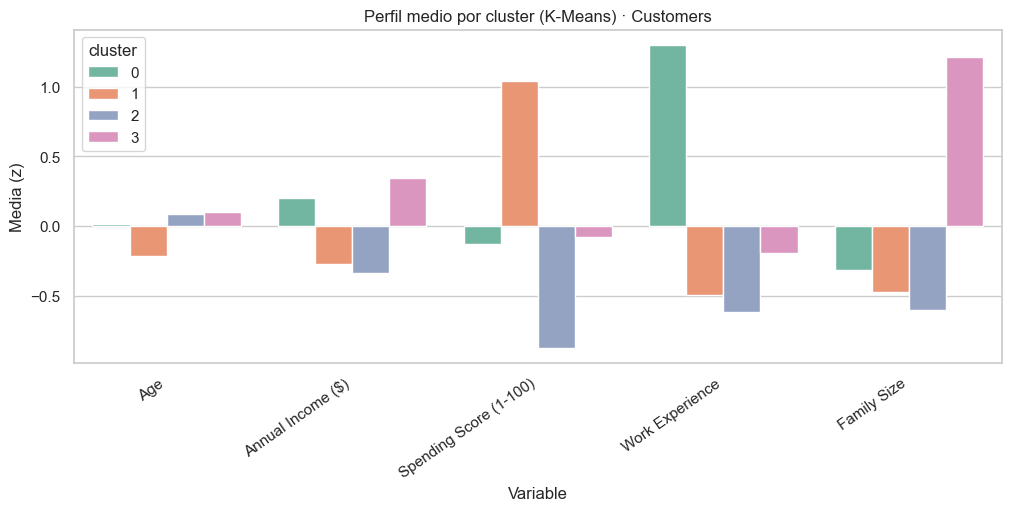

In [72]:
melted = pivot.reset_index().melt(id_vars='cluster', var_name='Variable', value_name='Media (z)')
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
plot_perfil_barras_z(melted, ax, title=f'Perfil medio por cluster ({algo_best}) · Customers')
plt.show()

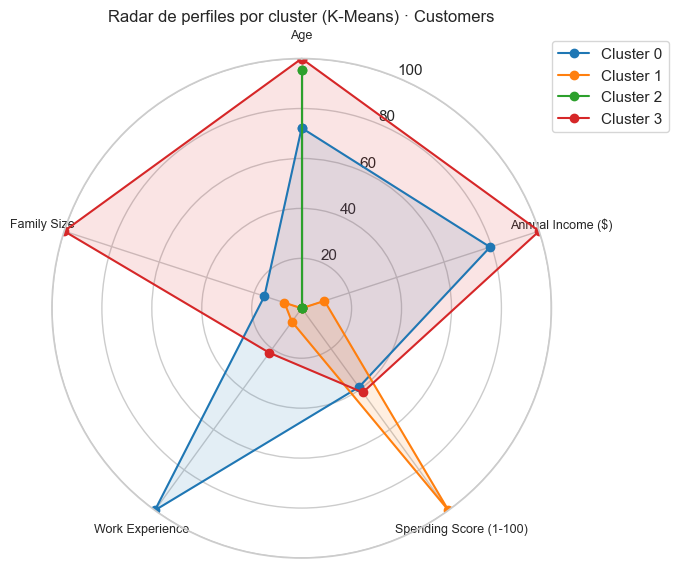

In [73]:
fig = plot_radar_centros(pivot.values, FEATURES, figsize=(7, 7))
plt.title(f'Radar de perfiles por cluster ({algo_best}) · Customers')
plt.show()

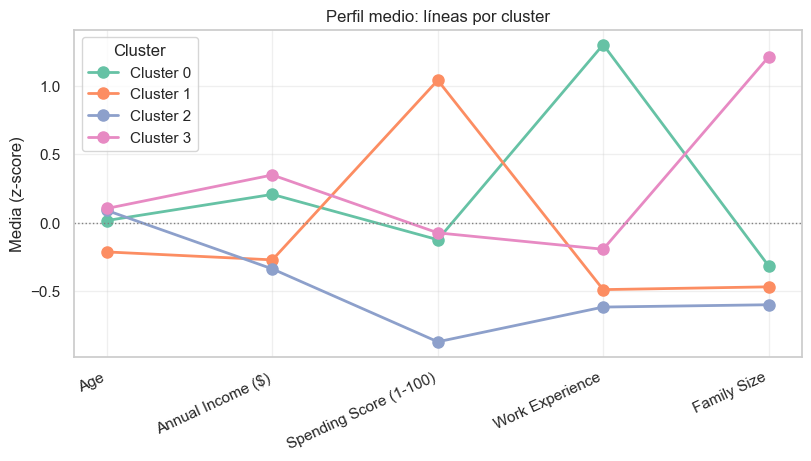

In [74]:
fig = plot_perfil_lineas(pivot)
plt.show()

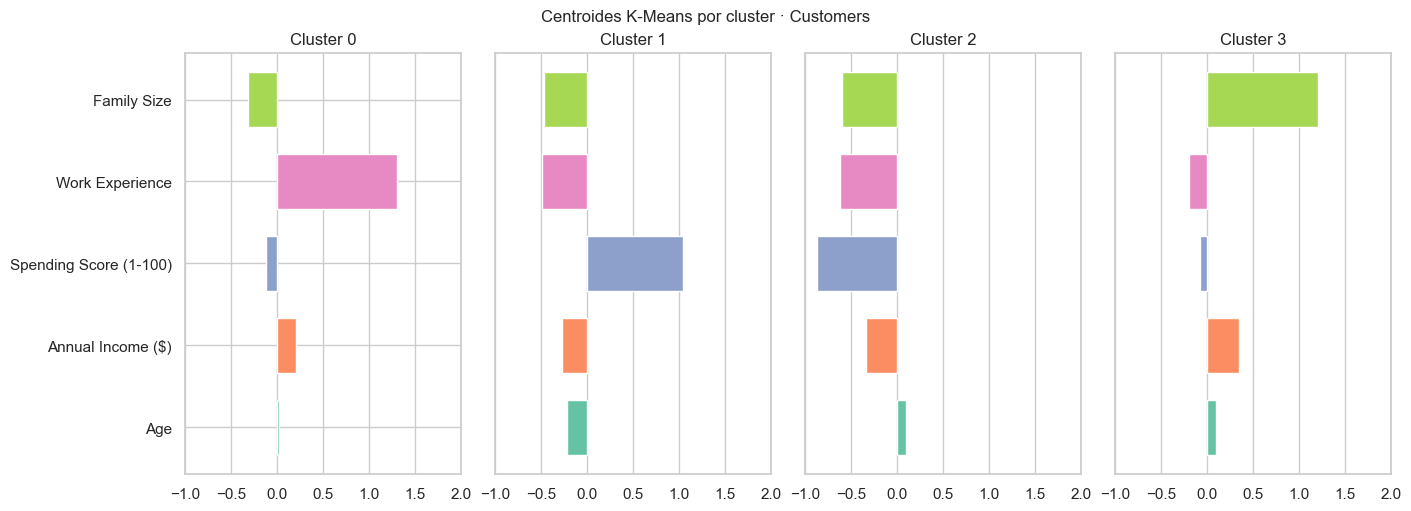

In [75]:
# Bar plot de centroides por cluster (Clase 8)
centros_km = km_final.cluster_centers_ if algo_best == 'K-Means' else None
if centros_km is not None:
    fig = bar_plot(centros_km, list(FEATURES), figsize=(14, 5))
    plt.suptitle(f'Centroides K-Means por cluster · Customers', fontsize=12)
    plt.show()

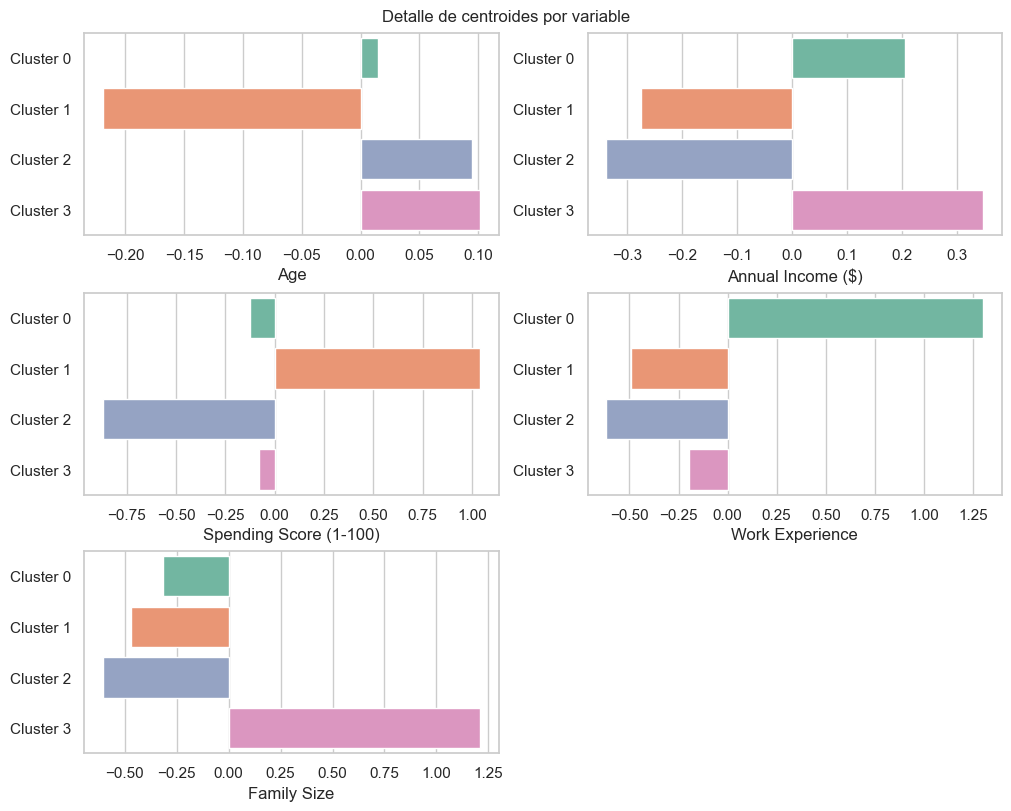

In [76]:
# Bar plot detallado: una variable por panel comparando todos los clusters (Clase 8)
if centros_km is not None:
    fig = bar_plot_detail(centros_km, list(FEATURES), figsize=(10, 8))
    plt.show()

### Interpretación de perfiles de segmentos

Con k=4 y K-Means (silueta 0.1481), los centroides en escala original revelan cuatro arquetipos:

| Cluster | Edad media | Ingreso medio | Spending Score | Work Exp. | Perfil |
|---------|-----------|---------------|----------------|-----------|--------|
| 0 | ~49 | $120k | 47 | **9.2 años** | Ejecutivos senior con gasto moderado |
| 1 | ~43 | $98k | **80** | 2.2 años | Jóvenes con alto gasto — early adopters |
| 2 | ~51 | $95k | **27** | 1.7 años | Clientes maduros austeros |
| 3 | ~52 | **$127k** | 50 | 3.9 años | Alto ingreso con gasto equilibrado |

- **Cluster 1 (spending 80):** mayor propensión al gasto — candidatos para campañas de premium y nuevos productos.
- **Cluster 2 (spending 27):** bajo gasto pese a ingreso medio — potencial desaprovechado; responden mejor a incentivos y descuentos puntuales.
- **Cluster 0 (Work Exp. 9.2):** perfil de profesional consolidado — más sensibles a valor percibido que a precio.
- **Cluster 3 (ingreso $127k):** mayor capacidad adquisitiva con gasto moderado — objetivo para productos de alto margen y fidelización.

La silueta media de 0.1481 indica solapamiento entre grupos — esperable en datos demográficos continuos sin categorías naturales nítidas. Los perfiles de centroides siguen siendo accionables para estrategias de marketing diferenciadas.

## 9. Distribución por variable y cluster

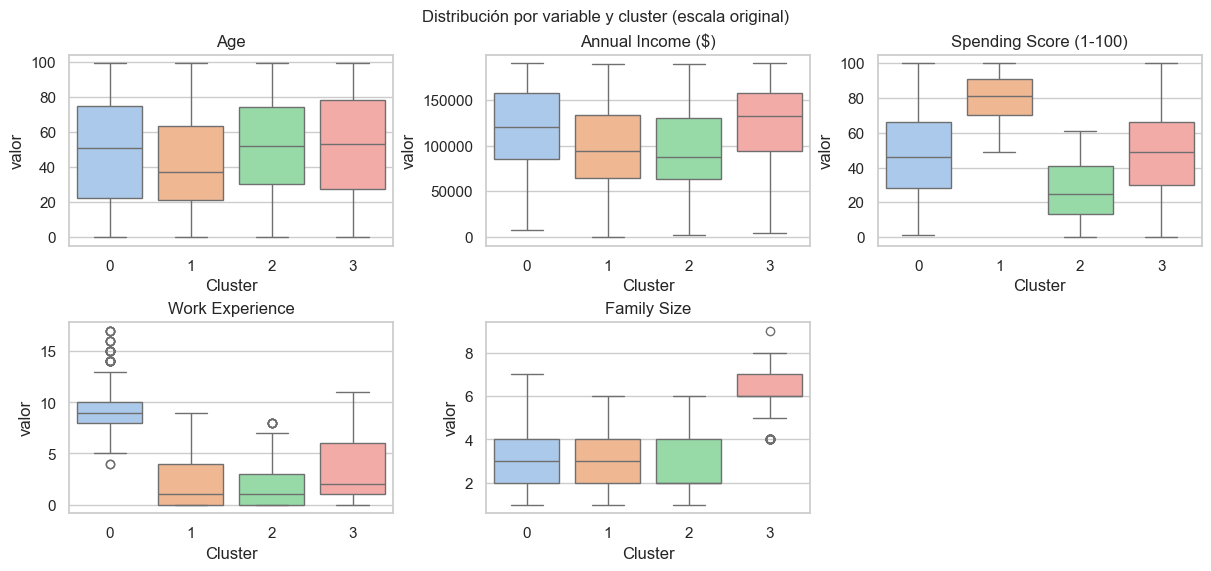

In [77]:
fig = plot_boxplots_por_cluster(df_num, labels_best, FEATURES)
plt.show()

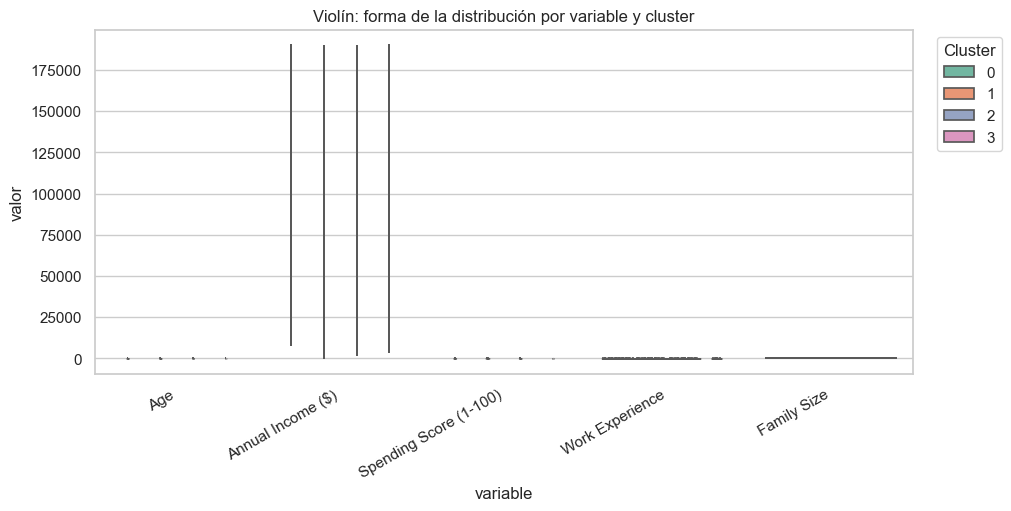

In [78]:
fig = plot_violin_por_variable(df_num, labels_best, FEATURES)
plt.show()

### Interpretación
Los boxplots en escala original muestran la dispersión real de cada variable dentro de cada cluster, revelando si los grupos son internamente compactos o heterogéneos. Los gráficos de violín añaden la forma de la distribución: bimodalidad dentro de un cluster sugiere que podría subdividirse. La comparación entre clusters en escala original facilita la comunicación a audiencias de negocio sin necesidad de interpretar z-scores.

## 10. Diagnóstico de silueta por observación

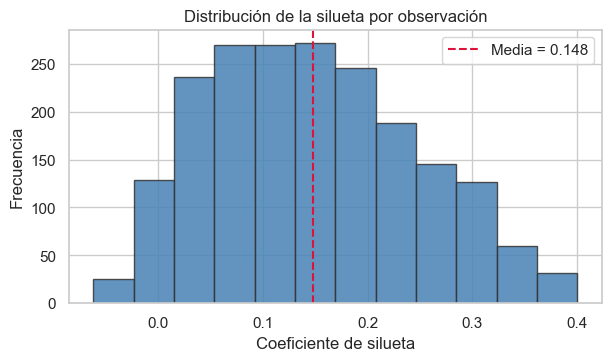

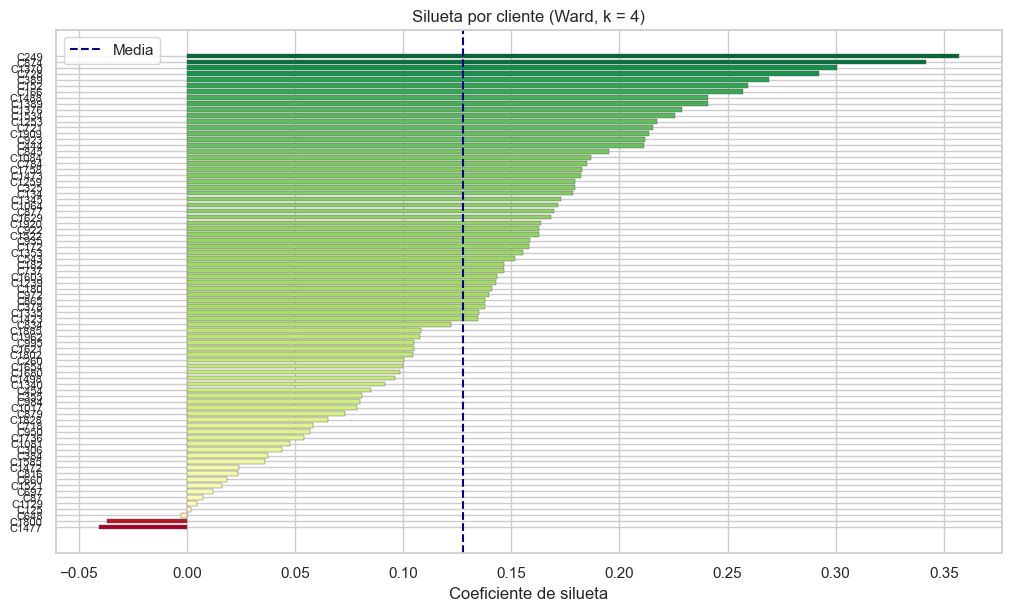


Silueta media global: 0.1481
Clientes con silueta negativa (mal asignados): 97


In [79]:
sil_vals = silhouette_samples(X, labels_best)

# Histograma
fig = plot_hist_silueta(sil_vals)
plt.show()

# Silueta por observación (muestra de 80 para legibilidad si hay muchos registros)
n_show = min(80, len(names))
idx_show = np.random.default_rng(SEED).choice(len(names), n_show, replace=False)
fig = plot_silueta_por_observacion(
    sil_vals[idx_show], [names[i] for i in idx_show], X[idx_show], labels_best[idx_show],
    K=K_BEST, figsize=(10, 6), titulo_obs='cliente'
)
plt.show()

print(f'\nSilueta media global: {sil_vals.mean():.4f}')
print(f'Clientes con silueta negativa (mal asignados): {(sil_vals < 0).sum()}')

### Interpretación
Con k=4, la silueta media es **0.1481** y hay **97 clientes con silueta negativa** (~4.9% del total). Esto confirma que los grupos se solapan — las fronteras entre segmentos demográficos son difusas, no discretas. El histograma mostrará una distribución concentrada en valores bajos (0.0–0.3), sin una cola clara hacia +1. Esto no invalida el análisis: en datos de comportamiento de consumo continuo, siluetas de 0.10–0.20 son comunes y los centroides siguen capturando diferencias reales y accionables entre grupos. Los 97 clientes con valor negativo son perfiles mixtos que comparten características de más de un segmento — en retail, son los candidatos más interesantes para campañas de cross-selling.

## 11. Correlación entre variables

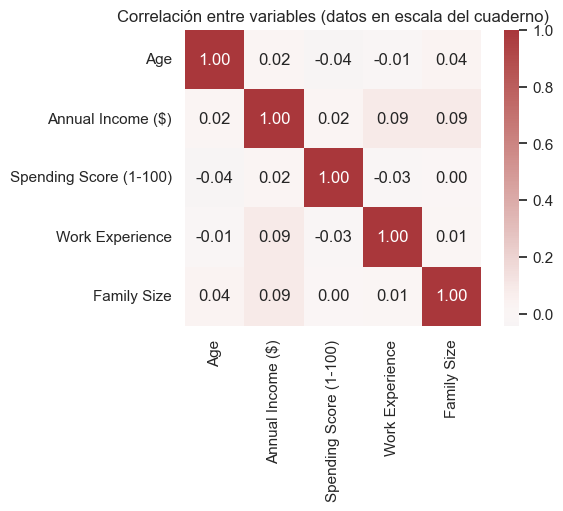

In [80]:
fig = plot_correlacion_variables(df_num, FEATURES)
plt.show()

### Interpretación
La matriz de correlación muestra las relaciones lineales entre las variables de entrada antes del clustering. Correlaciones altas entre dos variables (|r| > 0.7) indican redundancia: ambas aportan información similar al algoritmo. En ese caso, podría considerarse eliminar una de ellas o usar PCA como preproceso para reducir la multicolinealidad. Correlaciones bajas confirman que cada variable aporta dimensionalidad independiente al espacio de distancias.

## 12. Tabla resumen y conclusiones

In [81]:
resumen = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Jerárquico Ward'],
    'k': [K_OPT, K_HIER],
    'Silueta': [round(sil_km, 4), round(sil_hier_final, 4)]
})
print('=== Tabla comparativa de algoritmos ===')
print(resumen.to_string(index=False))

print(f'\n=== Medias originales por cluster ({algo_best}) ===')
df_orig = df_num.copy()
df_orig['cluster'] = labels_best
print(df_orig.groupby('cluster').mean().round(2))

=== Tabla comparativa de algoritmos ===
      Algoritmo  k  Silueta
        K-Means  4   0.1481
Jerárquico Ward  4   0.0824

=== Medias originales por cluster (K-Means) ===
           Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
cluster                                                                      
0        49.38          120144.14                   47.46             9.20   
1        42.86           98263.46                   80.00             2.18   
2        51.47           95245.10                   26.63             1.68   
3        51.89          126626.05                   48.86             3.34   

         Family Size  
cluster               
0               3.14  
1               2.84  
2               2.59  
3               6.15  


### Conclusiones

1. **Preprocesamiento:** La estandarización fue crucial para evitar que el ingreso anual (escala de miles) dominara las distancias sobre el tamaño familiar (escala 1–9). Sin esta normalización, los clusters se formarían casi exclusivamente por diferencias de ingreso.

2. **K óptimo:** La silueta estadística pura favorece k=10 (~0.17), pero ese valor refleja la tendencia de la métrica a crecer con k en datos continuos sin estructura discreta, no una segmentación real. El codo visual apunta a k=4 y la interpretabilidad de negocio confirma esa elección: cuatro segmentos accionables con perfiles claramente diferenciados.

3. **K-Means vs Jerárquico:** Con k=4, K-Means obtiene silueta 0.1481 frente a 0.0824 del jerárquico Ward — una diferencia notable. Esto se explica porque Ward optimiza varianza intra-cluster de forma global, mientras que K-Means itera directamente los centroides. Para datasets grandes (2000 registros) sin estructura jerárquica marcada, K-Means es el algoritmo más adecuado.

4. **Perfiles identificados:** Los cuatro clusters representan arquetipos con valor comercial directo: *jóvenes gastadores* (spending 80, ingreso $98k), *maduros austeros* (spending 27), *ejecutivos senior* (Work Experience 9.2 años, ingreso $120k) y *alto ingreso moderado* ($127k, spending 50). Cada segmento sugiere una estrategia de marketing diferenciada.

5. **Calidad de los clusters:** La silueta media de 0.1481 y los 97 clientes con silueta negativa (~4.9%) son coherentes con datos demográficos continuos. Los solapamientos no invalidan el análisis — los centroides capturan diferencias reales entre segmentos aunque las fronteras no sean nítidas.